<a href="https://colab.research.google.com/github/feandresilva/exercicios_Pandas/blob/main/dataframe_comercio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import plotly.express as px
from scipy import stats
from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt
df_produtos = pd.read_csv("https://cognitrilha.com.br/datasets/lojinha_bairro_produtos_abril_2026.csv.gz")
df_vendas = pd.read_csv("https://cognitrilha.com.br/datasets/lojinha_bairro_vendas_abril_2026.csv.gz")
display(df_produtos)
display(df_vendas)

,codigo_barras,produto,marca,preco
0,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90
1,7892604000028,Arroz Parboilizado 5kg,Graonoro,27.80
2,7892604000035,Feijao Carioca 1kg,Rancho Lume,8.49
3,7892604000042,Feijao Preto 1kg,Rancho Lume,8.79
4,7892604000059,Acucar Cristal 1kg,Docevia,4.59
...,...,...,...,...
123,7892604001247,Pilha Alcalina AA 4un,Luzetta,13.90
124,7892604001254,Fosforo Caixa 10un,Chamaluz,4.49
125,7892604001261,Vela Branca 8un,Chamaluz,7.99
126,7892604001278,Guardanapo Papel 50un,Papelora,4.29


,data_hora,operador,produto_codigo_barras,quantidade,preco_unitario,forma_pagamento
0,2026-04-01 07:17:15,Ana Costa,7892604000448,3,4.59,Debito
1,2026-04-01 07:17:15,Ana Costa,7892604000837,1,9.99,Debito
2,2026-04-01 07:32:40,Marta Reis,7892604000745,1,8.49,Pix
3,2026-04-01 07:36:26,Ana Costa,7892604000028,5,27.80,Pix
4,2026-04-01 07:36:26,Ana Costa,7892604000035,5,8.49,Pix
...,...,...,...,...,...,...
4395,2026-04-30 20:54:40,Carla Nunes,7892604001209,1,6.99,Pix
4396,2026-04-30 21:13:57,Carla Nunes,7892604000318,2,1.69,Debito
4397,2026-04-30 21:13:57,Carla Nunes,7892604000721,3,2.49,Debito
4398,2026-04-30 21:13:57,Carla Nunes,7892604000936,1,7.49,Debito



Crie 2 DataFrames do pandas com os dados dos arquivos acima.

Crie um DataFrame unificado (use pd.merge). Utilize o código de barras como coluna em comum para o merge. (se necessário, veja a documentação do pd.merge)

Crie uma coluna "subtotal" igual a quantidade multiplicado pelo preço unitário.

Crie as colunas "ano", "mes" e "dia" utilizando pd.to_datetime e o .dt

Exiba em um gráfico de linhas a evolução da receita total por dia

Faça uma apresentação por meio de tabela da média, mediana, moda, variância e desvio-padrão da coluna "subtotal"

Faça o gráfico de histograma da variável quantitativa "subtotal"

Faça o grafico de barras: Distribuição de vendas por método de pagamento

Realize o teste de hipótese abaixo:
H0: Não há diferença no subtotal médio entre Pix e Crédito
H1: Há diferença significativa no subtotal médio

Verifique a assimetria da coluna subtotal (utilize o .skew()).
assimetria entre -0.5 e 0.5: aproximadamente simétrica
assimetria fora desse intervalo: assimétrica

Outra forma de verificar a normalidade dos dados é utilizando o stats.probplot() com o parâmetro dist="norm".
Exiba os gráficos para as variáveis quantitativas quantidade e preco unitario.

Agrupe o faturamento total por dia.
Em seguida, utilize regressão linear simples para estimar a tendência das vendas e prever o faturamento dos próximos dias.
(utilize stats.linregress())

Faça um gráfico boxplot que exiba os dados do subtotal para cada semana do mês.

In [ ]:
#Crie um DataFrame unificado (use pd.merge). Utilize o código de barras como coluna em comum para o merge.
df_produtos = df_produtos.rename(columns={"codigo_barras": "produto_codigo_barras"})
df_unificado = df_produtos.merge(df_vendas, on="produto_codigo_barras", how= "inner")
df_unificado

,produto_codigo_barras,produto,marca,preco,data_hora,operador,quantidade,preco_unitario,forma_pagamento
0,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 12:40:24,Bruno Lima,1,29.90,Pix
1,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 21:33:29,Diego Rocha,1,29.90,Pix
2,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-03 17:03:12,Diego Rocha,2,29.90,Debito
3,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 10:12:22,Marta Reis,1,29.90,Pix
4,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 13:22:54,Diego Rocha,2,29.90,Credito
...,...,...,...,...,...,...,...,...,...
4395,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-20 13:35:50,Marta Reis,2,9.99,Pix
4396,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-22 07:59:45,Ana Costa,1,9.99,Credito
4397,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-27 08:31:21,Ana Costa,1,9.99,Credito
4398,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-29 19:59:18,Carla Nunes,1,9.99,Debito


In [ ]:
#Crie uma coluna "subtotal" igual a quantidade multiplicado pelo preço unitário.
df_unificado["subtotal"] = df_unificado["quantidade"] * df_unificado["preco_unitario"]
df_unificado

,produto_codigo_barras,produto,marca,preco,data_hora,operador,quantidade,preco_unitario,forma_pagamento,subtotal
0,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 12:40:24,Bruno Lima,1,29.90,Pix,29.90
1,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 21:33:29,Diego Rocha,1,29.90,Pix,29.90
2,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-03 17:03:12,Diego Rocha,2,29.90,Debito,59.80
3,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 10:12:22,Marta Reis,1,29.90,Pix,29.90
4,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 13:22:54,Diego Rocha,2,29.90,Credito,59.80
...,...,...,...,...,...,...,...,...,...,...
4395,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-20 13:35:50,Marta Reis,2,9.99,Pix,19.98
4396,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-22 07:59:45,Ana Costa,1,9.99,Credito,9.99
4397,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-27 08:31:21,Ana Costa,1,9.99,Credito,9.99
4398,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-29 19:59:18,Carla Nunes,1,9.99,Debito,9.99


In [ ]:
#Crie as colunas "ano", "mes" e "dia" utilizando pd.to_datetime e o .dt
df_unificado["ano"] = pd.to_datetime(df_unificado["data_hora"]).dt.year
df_unificado["mes"] = pd.to_datetime(df_unificado["data_hora"]).dt.month
df_unificado["dia"] = pd.to_datetime(df_unificado["data_hora"]).dt.day
df_unificado

,produto_codigo_barras,produto,marca,preco,data_hora,operador,quantidade,preco_unitario,forma_pagamento,subtotal,ano,mes,dia
0,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 12:40:24,Bruno Lima,1,29.90,Pix,29.90,2026,4,1
1,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-01 21:33:29,Diego Rocha,1,29.90,Pix,29.90,2026,4,1
2,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-03 17:03:12,Diego Rocha,2,29.90,Debito,59.80,2026,4,3
3,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 10:12:22,Marta Reis,1,29.90,Pix,29.90,2026,4,5
4,7892604000011,Arroz Branco Tipo 1 5kg,Graonoro,29.90,2026-04-05 13:22:54,Diego Rocha,2,29.90,Credito,59.80,2026,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4395,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-20 13:35:50,Marta Reis,2,9.99,Pix,19.98,2026,4,20
4396,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-22 07:59:45,Ana Costa,1,9.99,Credito,9.99,2026,4,22
4397,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-27 08:31:21,Ana Costa,1,9.99,Credito,9.99,2026,4,27
4398,7892604001285,Copo Descartavel 200ml 100un,Casa Pratica,9.99,2026-04-29 19:59:18,Carla Nunes,1,9.99,Debito,9.99,2026,4,29


In [ ]:
#Exiba em um gráfico de linhas a evolução da receita total por dia
df_receita_total = df_unificado.groupby("dia")["subtotal"].sum()
df_receita_total = df_receita_total.reset_index()
df_receita_total = df_receita_total.rename(columns={"subtotal": "receita_total"})
fig = px.line(df_receita_total, x="dia", y="receita_total")
fig.show()

In [ ]:
#Exiba em um gráfico de barras a receita total de cada operador, em ordem decrescente
df_vendas_operador = df_unificado.groupby("operador")["subtotal"].sum().sort_values(ascending=False)
df_vendas_operador = df_vendas_operador.reset_index()
df_vendas_operador = df_vendas_operador.rename(columns={"subtotal": "Total", "operador": "Operador"})
fig = px.bar(df_vendas_operador, x="Operador", y="Total")
fig.show()

In [ ]:
#Faça uma apresentação por meio de tabela da média, mediana, moda, variância e desvio-padrão da coluna "subtotal"
df_dados_subtotal = df_unificado
df_dados_subtotal["media"] = df_dados_subtotal["subtotal"].mean()
df_dados_subtotal["mediana"] = df_dados_subtotal["subtotal"].median()
df_dados_subtotal["moda"] = df_dados_subtotal["subtotal"].mode()
df_dados_subtotal["variancia"] = df_dados_subtotal["subtotal"].var()
df_dados_subtotal["desvio_padrao"] = df_dados_subtotal["subtotal"].std()
df_subtotal_consolidado = df_dados_subtotal[["media", "mediana", "moda", "variancia", "desvio_padrao"]]
df_subtotal_consolidado.loc[0]

,0
media,11.911770
mediana,8.490000
moda,5.990000
variancia,117.002775
desvio_padrao,10.816782


In [ ]:
#Faça o gráfico de histograma da variável quantitativa "subtotal"
fig = px.histogram(df_unificado, x="subtotal")
fig.show()

In [ ]:
#Faça o grafico de barras: Distribuição de vendas por método de pagamento
df_metodos_pagamentos = df_unificado["forma_pagamento"].value_counts()
df_metodos_pagamentos = df_metodos_pagamentos.reset_index()
df_metodos_pagamentos = df_metodos_pagamentos.rename(columns={"count": "total"})
fig = px.bar(df_metodos_pagamentos, x="forma_pagamento", y="total")
fig.show()

In [ ]:
#Realize o teste de hipótese abaixo:
#H0: Não há diferença no subtotal médio entre Pix e Crédito
#H1: Há diferença significativa no subtotal médio
#Utilize a função stats.ttest_ind(...)
df_pix = df_unificado[df_unificado["forma_pagamento"] == "Pix"]
df_pix = df_pix["subtotal"]
df_credito = df_unificado[df_unificado["forma_pagamento"] == "Credito"]
df_credito = df_credito["subtotal"]
stats.ttest_ind(df_pix, df_credito)

TtestResult(statistic=np.float64(-3.6768991003242886), pvalue=np.float64(0.00024058011981970367), df=np.float64(2765.0))

In [ ]:
#Verifique a assimetria da coluna subtotal (utilize o .skew()).
#assimetria entre -0.5 e 0.5: aproximadamente simétrica
#assimetria fora desse intervalo: assimétrica
df_teste_assimetria = df_unificado["subtotal"]
skew(df_teste_assimetria)

np.float64(3.7307611637713762)

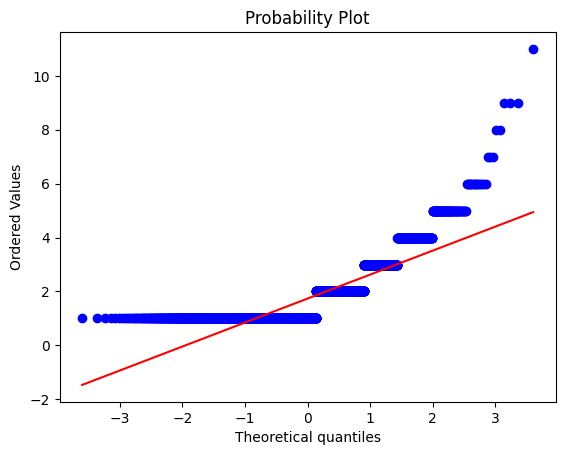

In [ ]:
#Outra forma de verificar a normalidade dos dados é utilizando o stats.probplot() com o parâmetro dist="norm".
#Exiba os gráficos para as variáveis quantitativas quantidade e preco unitario.
df_normalidade_quantidade = df_unificado["quantidade"]
df_normalidade_preco = df_unificado["preco_unitario"]
res = stats.probplot(df_normalidade_quantidade, plot=plt)
plt.show()

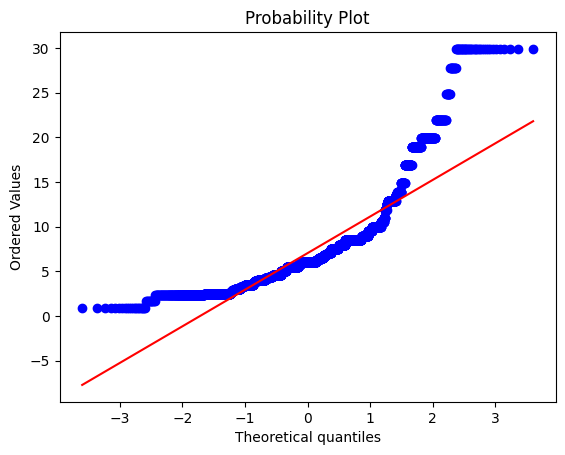

In [ ]:
res = stats.probplot(df_normalidade_preco, plot=plt)
plt.show()

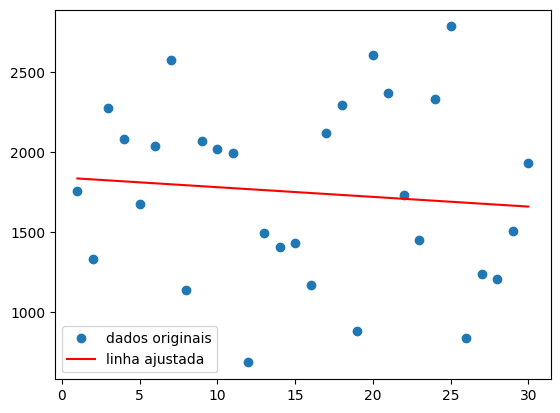

In [ ]:
#Agrupe o faturamento total por dia.
#Em seguida, utilize regressão linear simples para estimar a tendência das vendas e prever o faturamento dos próximos dias.
#(utilize stats.linregress())
df_regressao_linear = df_unificado.groupby("dia")["subtotal"].sum()
df_regressao_linear = df_regressao_linear.reset_index()
df_regressao_linear = df_regressao_linear.rename(columns={"subtotal": "total"})
df_x = df_regressao_linear["dia"]
df_y = df_regressao_linear["total"]
res = stats.linregress(df_x, df_y)
plt.plot(df_x, df_y, 'o', label='dados originais')
plt.plot(df_x, res.intercept + res.slope*df_x, 'r', label='linha ajustada')
plt.legend()
plt.show()

In [ ]:
#Faça um gráfico boxplot que exiba os dados do subtotal para cada semana do mês.
df_unificado["semana"] =  (df_unificado["dia"]-1)//7 + 1
df_boxplot = df_unificado
df_boxplot = df_boxplot.rename(columns={"subtotal": "total"})
fig = px.box(df_boxplot, x="semana", y="total")
fig.show()